
# Day 26 — Early Stopping, Logistic Regression & Softmax Regression

- Explain **early stopping** as a form of regularization.
- Use a validation set to decide when training should stop.
- Understand logistic regression as a probability model.
- Explain the **sigmoid function**, log loss, decision threshold, and decision boundary.
- Train binary logistic regression with scikit-learn.
- Understand the multiclass extension: **Softmax regression**.
- Explain Softmax probabilities, cross-entropy cost, and class prediction.



# Part 1 — Early Stopping

## What problem does early stopping solve?

Suppose we train a model for many iterations.

At first:

- training error ↓
- validation error ↓

Eventually the model may begin fitting noise:

- training error ↓
- validation error ↑

That is **overfitting**.

### Early stopping

Stop training when validation performance stops improving.

A simple mental picture:

```text
Error
 ^
 |\                 Training error
 | \____________________
 |  \             /
 |   \           /  Validation error
 |    \_________/
 +--------------------------> Training iterations
             ^
             |
        stop here
```

The important point:

> We do not necessarily want the model with the lowest training error. We want the model that generalizes best.


In [14]:

# Imports for today's notebook

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    classification_report
)

np.random.seed(42)



## 1.1 Early stopping from scratch with polynomial regression

We will deliberately create a model that is capable of becoming too complex.

The model will be trained using `SGDRegressor`.

We will monitor validation error after every training epoch.

The logic is:

1. Fit one more epoch.
2. Calculate training error.
3. Calculate validation error.
4. Remember the best validation model.
5. Stop after validation performance has not improved for several epochs.


In [15]:

# Create a small nonlinear dataset

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y.ravel(), test_size=0.2, random_state=42
)

# High-degree polynomial features make overfitting possible.
poly_scaler = Pipeline([
    ("poly", PolynomialFeatures(degree=90, include_bias=False)),
    ("std", StandardScaler())
])

X_train_poly = poly_scaler.fit_transform(X_train)
X_val_poly = poly_scaler.transform(X_val)

print("Training shape:", X_train_poly.shape)
print("Validation shape:", X_val_poly.shape)


Training shape: (80, 90)
Validation shape: (20, 90)


In [16]:

# Early stopping manually

sgd_reg = SGDRegressor(
    max_iter=1,
    tol=None,
    penalty=None,
    learning_rate="constant",
    eta0=0.0005,
    random_state=42
)

n_epochs = 500
patience = 20

best_val_error = float("inf")
best_model = None
best_epoch = None
epochs_without_improvement = 0

train_errors = []
val_errors = []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_poly, y_train)

    train_pred = sgd_reg.predict(X_train_poly)
    val_pred = sgd_reg.predict(X_val_poly)

    train_error = np.mean((train_pred - y_train) ** 2)
    val_error = np.mean((val_pred - y_val) ** 2)

    train_errors.append(train_error)
    val_errors.append(val_error)

    if val_error < best_val_error:
        best_val_error = val_error
        best_model = SGDRegressor(
            max_iter=1,
            tol=None,
            penalty=None,
            learning_rate="constant",
            eta0=0.0005,
            random_state=42
        )
        best_model.coef_ = sgd_reg.coef_.copy()
        best_model.intercept_ = sgd_reg.intercept_.copy()
        best_model.n_features_in_ = sgd_reg.n_features_in_
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

print("Best epoch:", best_epoch + 1)
print("Best validation MSE:", best_val_error)


Early stopping at epoch 28
Best epoch: 8
Best validation MSE: 12.907786471487437


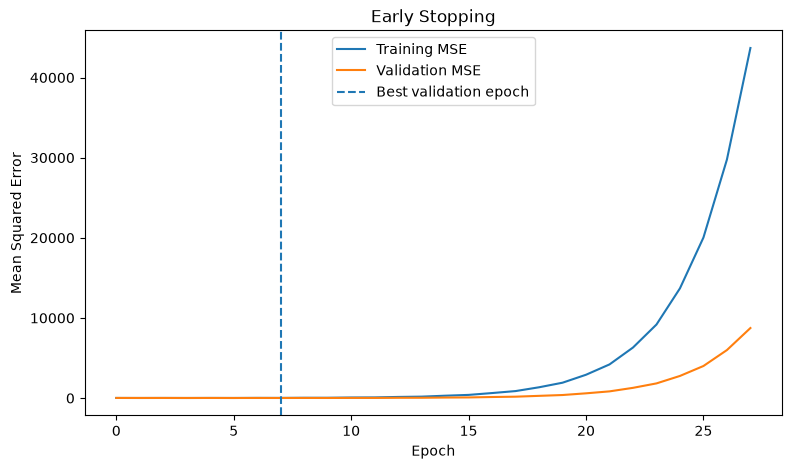

In [17]:

# Visualize training and validation error

plt.figure(figsize=(9, 5))
plt.plot(train_errors, label="Training MSE")
plt.plot(val_errors, label="Validation MSE")
plt.axvline(best_epoch, linestyle="--", label="Best validation epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Early Stopping")
plt.legend()
plt.show()



### Key takeaway

Early stopping is not a completely different optimization algorithm.

It is a **training-control strategy**:

> Continue optimizing while validation performance improves; stop when it stops improving.

This is especially useful for iterative algorithms such as Gradient Descent and neural networks.



# Part 2 — Logistic Regression

## 2.1 From linear output to probability

Linear regression predicts:

`y = θ₀ + θ₁x₁ + θ₂x₂ + ...`

Logistic regression first calculates a linear score:

`z = θᵀx`

Then it passes `z` through the **sigmoid function**:

`σ(z) = 1 / (1 + exp(-z))`

The result is between 0 and 1:

- `σ(z) ≈ 0` → likely class 0
- `σ(z) ≈ 0.5` → uncertain
- `σ(z) ≈ 1` → likely class 1

For binary classification:

`P(y=1 | x) = σ(θᵀx)`

### Important distinction

The linear equation produces a **score**.

The sigmoid converts that score into a **probability-like value**.

Then we choose a class using a threshold, commonly 0.5.


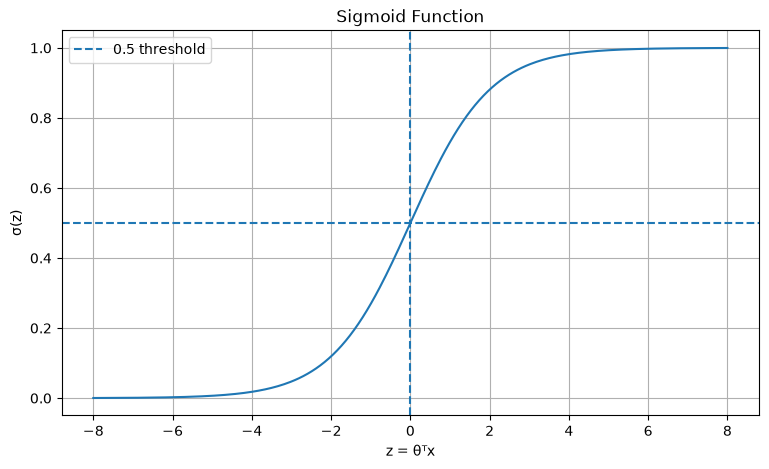

z=-5: probability=0.0067
z=-2: probability=0.1192
z= 0: probability=0.5000
z= 2: probability=0.8808
z= 5: probability=0.9933


In [18]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
probabilities = sigmoid(z)

plt.figure(figsize=(9, 5))
plt.plot(z, probabilities)
plt.axhline(0.5, linestyle="--", label="0.5 threshold")
plt.axvline(0, linestyle="--")
plt.xlabel("z = θᵀx")
plt.ylabel("σ(z)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(True)
plt.show()

for value in [-5, -2, 0, 2, 5]:
    print(f"z={value:>2}: probability={sigmoid(value):.4f}")



## 2.2 Logistic regression cost function

For one training example:

`J(θ) = -[y log(p) + (1-y) log(1-p)]`

where:

- `y` = true class (0 or 1)
- `p` = predicted probability

Why does this make sense?

### If y = 1

The cost becomes:

`-log(p)`

So:

- p = 0.99 → very small cost
- p = 0.50 → larger cost
- p = 0.01 → huge cost

### If y = 0

The cost becomes:

`-log(1-p)`

So a confident wrong prediction is heavily punished.

This is called **log loss** or **binary cross-entropy**.


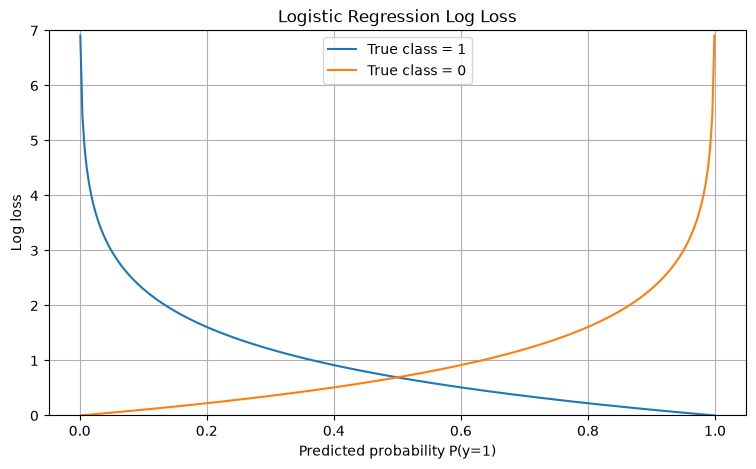

In [19]:

# See how log loss behaves for different probabilities

p = np.linspace(0.001, 0.999, 300)

loss_if_y1 = -np.log(p)
loss_if_y0 = -np.log(1 - p)

plt.figure(figsize=(9, 5))
plt.plot(p, loss_if_y1, label="True class = 1")
plt.plot(p, loss_if_y0, label="True class = 0")
plt.xlabel("Predicted probability P(y=1)")
plt.ylabel("Log loss")
plt.title("Logistic Regression Log Loss")
plt.ylim(0, 7)
plt.legend()
plt.grid(True)
plt.show()



## 2.3 Train logistic regression with scikit-learn

We will use the Iris dataset.

To make it binary, we will predict:

- class 0: Iris-Setosa
- class 1: not Iris-Setosa

This lets us focus on binary logistic regression first.


In [20]:

iris = load_iris()

X = iris["data"][:, [2, 3]]  # petal length and petal width
y = (iris["target"] == 0).astype(int)  # Setosa vs not Setosa

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0
Log loss: 0.023667596002754678
Confusion matrix:
[[25  0]
 [ 0 13]]



## 2.4 Probability vs prediction

Use:

`predict_proba(X)` → probabilities

`predict(X)` → final class labels

For binary logistic regression, the usual rule is:

`if P(class=1) >= 0.5 → predict class 1`

The threshold can be changed depending on the problem.

For example, in a medical screening problem, we may prefer higher recall and use a lower threshold.

**Important:** the threshold is a decision rule; it is not the same thing as changing the model itself.


In [21]:

sample = X_test[:10]

probs = log_reg.predict_proba(sample)
preds = log_reg.predict(sample)

for i, (prob, pred) in enumerate(zip(probs, preds)):
    print(
        f"Example {i+1}: "
        f"P(class 0)={prob[0]:.3f}, "
        f"P(class 1)={prob[1]:.3f}, "
        f"prediction={pred}"
    )


Example 1: P(class 0)=0.989, P(class 1)=0.011, prediction=0
Example 2: P(class 0)=0.999, P(class 1)=0.001, prediction=0
Example 3: P(class 0)=0.994, P(class 1)=0.006, prediction=0
Example 4: P(class 0)=0.981, P(class 1)=0.019, prediction=0
Example 5: P(class 0)=0.997, P(class 1)=0.003, prediction=0
Example 6: P(class 0)=0.999, P(class 1)=0.001, prediction=0
Example 7: P(class 0)=0.039, P(class 1)=0.961, prediction=1
Example 8: P(class 0)=0.039, P(class 1)=0.961, prediction=1
Example 9: P(class 0)=0.039, P(class 1)=0.961, prediction=1
Example 10: P(class 0)=0.030, P(class 1)=0.970, prediction=1



# Part 3 — Logistic Regression Decision Boundary

The decision boundary is where the model is equally likely to choose either class.

For binary logistic regression with threshold 0.5:

`P(y=1|x) = 0.5`

Since:

`σ(z) = 0.5` when `z = 0`

the boundary is:

`θᵀx = 0`

This is why logistic regression creates a **linear decision boundary** in the original feature space.


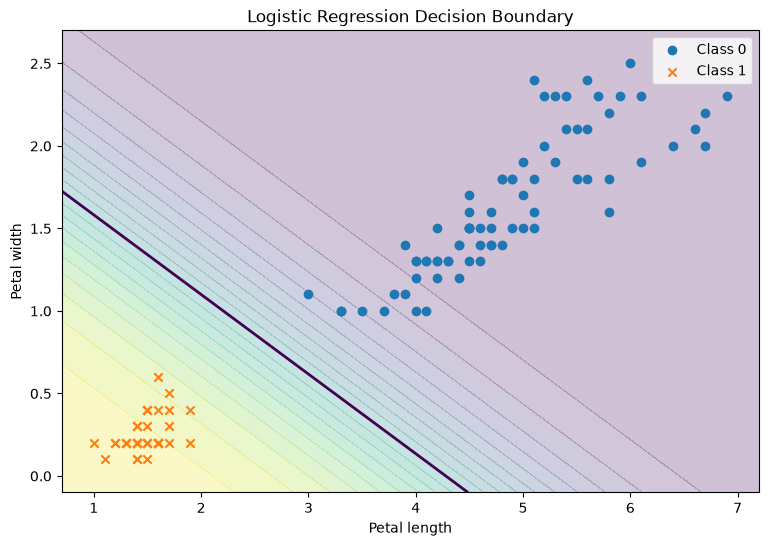

In [22]:

# Visualize the decision boundary

model = log_reg.named_steps["model"]
scaler = log_reg.named_steps["scaler"]

X_train_scaled = scaler.transform(X_train)

x0_min, x0_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x1_min, x1_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 300),
    np.linspace(x1_min, x1_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
prob = model.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, prob, levels=20, alpha=0.25)
plt.contour(xx, yy, prob, levels=[0.5], linewidths=2)

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="o",
    label="Class 0"
)
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="x",
    label="Class 1"
)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()



# Part 4 — Softmax Regression

Binary logistic regression handles two classes.

What about three or more classes?

**Softmax Regression** generalizes logistic regression to multiclass classification.

Instead of one probability for class 1, the model calculates a score for every class:

`score_k(x) = θ_kᵀx`

Then Softmax converts all class scores into probabilities:

`P(y=k|x) = exp(score_k) / Σ exp(score_j)`

### Key property

All class probabilities add up to 1.

Example:

| Class | Probability |
|---|---:|
| Setosa | 0.97 |
| Versicolor | 0.02 |
| Virginica | 0.01 |

Prediction = class with the highest probability.

### Cost function

Softmax regression uses **cross-entropy loss**.

For one example:

`J(Θ) = -Σ y_k log(p_k)`

where `y_k` is 1 for the true class and 0 for all other classes.


In [23]:

# Softmax probabilities from scratch

def softmax(scores):
    # Subtracting max improves numerical stability.
    exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
    return exp_scores / exp_scores.sum(axis=1, keepdims=True)

scores = np.array([
    [2.0, 1.0, 0.1],
    [0.1, 2.5, 0.2],
    [0.2, 0.3, 3.0]
])

probs = softmax(scores)

print("Scores:")
print(scores)

print("\nSoftmax probabilities:")
print(np.round(probs, 4))

print("\nProbability sums:")
print(probs.sum(axis=1))


Scores:
[[2.  1.  0.1]
 [0.1 2.5 0.2]
 [0.2 0.3 3. ]]

Softmax probabilities:
[[0.659  0.2424 0.0986]
 [0.0762 0.8396 0.0842]
 [0.0539 0.0596 0.8865]]

Probability sums:
[1. 1. 1.]



## 4.1 Train multiclass Logistic Regression / Softmax Regression

In scikit-learn, `LogisticRegression` supports multiclass classification.

For a multinomial problem, the model learns a parameter vector for each class and uses the Softmax formulation.

We will use all three Iris classes.


In [24]:
X = iris["data"]
y = iris["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

softmax_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver="lbfgs"
    ))
])

softmax_reg.fit(X_train, y_train)

y_pred = softmax_reg.predict(X_test)
y_prob = softmax_reg.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_prob))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Accuracy: 0.9210526315789473
Log loss: 0.20896788754144632

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [25]:

# Inspect Softmax probabilities

for i in range(min(8, len(X_test))):
    print(
        f"True={iris.target_names[y_test[i]]:10s} | "
        f"Predicted={iris.target_names[y_pred[i]]:10s} | "
        f"Probabilities={np.round(y_prob[i], 3)}"
    )


True=setosa     | Predicted=setosa     | Probabilities=[0.985 0.015 0.   ]
True=versicolor | Predicted=versicolor | Probabilities=[0.034 0.621 0.345]
True=versicolor | Predicted=versicolor | Probabilities=[0.045 0.882 0.072]
True=versicolor | Predicted=versicolor | Probabilities=[0.011 0.916 0.073]
True=setosa     | Predicted=setosa     | Probabilities=[0.968 0.032 0.   ]
True=versicolor | Predicted=versicolor | Probabilities=[0.101 0.634 0.265]
True=virginica  | Predicted=versicolor | Probabilities=[0.002 0.547 0.451]
True=virginica  | Predicted=virginica  | Probabilities=[0.    0.053 0.947]



# Part 5 — Logistic Regression vs Softmax Regression

| Concept | Logistic Regression | Softmax Regression |
|---|---|---|
| Main use | Binary classification | Multiclass classification |
| Classes | Usually 2 | 3+ |
| Output | One class-1 probability | One probability per class |
| Function | Sigmoid | Softmax |
| Loss | Binary log loss | Cross-entropy |
| Prediction | Threshold probability | Highest probability |
| Boundary | Linear | Linear boundaries between classes |

### Remember

**Sigmoid:** one probability for binary classification.

**Softmax:** a probability distribution across multiple classes.


# Review last 5 learnings 

## 6.1 Linear Regression

Model:

`ŷ = θᵀx`

Typical cost:

`MSE = (1/m) Σ(ŷᵢ - yᵢ)²`

Three important training approaches:

1. Normal Equation
2. Batch Gradient Descent
3. Stochastic / Mini-batch Gradient Descent

---

## 6.2 Gradient Descent

Basic update:

`θ ← θ - η ∇θ J(θ)`

Where:

- `θ` = model parameters
- `η` = learning rate
- `∇θ J(θ)` = gradient of the cost function

If the learning rate is:

- too small → training is slow
- too large → training may diverge
- appropriate → cost generally decreases efficiently

---

## 6.3 Polynomial Regression

Add powers of the features:

`x → [x, x², x³, ...]`

This allows a linear model to fit nonlinear relationships.

But higher degree increases model complexity and overfitting risk.

---

## 6.4 Learning Curves

Plot training and validation error against training-set size.

Useful for diagnosing:

- underfitting
- overfitting
- high bias
- high variance

---

## 6.5 Regularized Linear Models

### Ridge

L2 penalty:

`α Σ θᵢ²`

### Lasso

L1 penalty:

`α Σ |θᵢ|`

### Elastic Net

Combination of L1 and L2.

Regularization generally reduces model complexity and can improve generalization.

---

## 6.6 Early Stopping

Another way to control complexity.

Instead of adding an explicit penalty, stop iterative training before the model overfits.

---

## 6.7 Logistic Regression

Binary classification:

`P(y=1|x) = σ(θᵀx)`

Uses sigmoid + log loss.

---

## 6.8 Softmax Regression

Multiclass classification:

`P(y=k|x) = exp(score_k) / Σ exp(score_j)`

Uses Softmax + cross-entropy.
